# DOWNLOAD SHAPEFILES FROM CENSUS FTP:

After downloading extract all in the folder and run the following block to load as complex np array

In [12]:
import requests
from bs4 import BeautifulSoup
import os

url = "https://www2.census.gov/geo/tiger/TIGER2025/CD/"
os.makedirs("CD_2025", exist_ok=True)

r = requests.get(url)
soup = BeautifulSoup(r.text, "html.parser")

for link in soup.find_all("a"):
    href = link.get("href")
    if href and href.endswith(".zip"):   # <-- FIXED: check that href is not None
        file_url = url + href
        file_path = os.path.join("2025_119_CD", href)
        print(f"Downloading {href}...")
        with requests.get(file_url, stream=True) as f:
            f.raise_for_status()
            with open(file_path, "wb") as out:
                for chunk in f.iter_content(chunk_size=8192):
                    out.write(chunk)
print("✅ All ZIP files downloaded to CD_2025/")

✅ All ZIP files downloaded to CD_2025/


In [34]:
import os, glob
import pandas as pd, numpy as np, geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.affinity import translate, scale
import matplotlib.pyplot as plt

folder = "./2025_119_CD"
shp_paths = glob.glob(os.path.join(folder, "*.shp"))
gdfs = [gpd.read_file(p) for p in shp_paths]
combined = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=gdfs[0].crs)

num_pts = 50
geoids, rows = [], []
skipped = 0

district_IDs = []

for idx, row in combined.iterrows():
    g = row.geometry
    if not g or g.is_empty:
        skipped += 1
        continue

    # Accept only a single Polygon (or a MultiPolygon that has exactly one part)
    if isinstance(g, Polygon):
        poly = g
    elif isinstance(g, MultiPolygon) and len(g.geoms) == 1:
        poly = list(g.geoms)[0]
    else:
        skipped += 1
        continue

    perim = poly.exterior.length
    if perim == 0:
        skipped += 1
        continue

    c = poly.centroid
    s = 1.0 / perim
    g2 = scale(translate(poly, xoff=-c.x, yoff=-c.y), xfact=s, yfact=s, origin=(0, 0))
    ext = g2.exterior
    total = ext.length or 1.0

    pts = [complex(ext.interpolate((k / num_pts) * total).x,
                   ext.interpolate((k / num_pts) * total).y)
           for k in range(num_pts)]

    geoids.append(idx)
    rows.append(np.array(pts, dtype=complex))
    district_IDs.append(f"{row.get('STATEFP')}_{row.get('CD119FP')}") 


arr = np.vstack(rows)                  # shape (n_polygons, num_pts)
df_complex = pd.DataFrame(arr, index=geoids, columns=[f"z_{i+1}" for i in range(num_pts)])
districts = df_complex.to_numpy().T    # final shape (num_pts, n_polygons)

print(f"Kept {len(rows)} polygons, skipped {skipped} features.")

np.save("district_outlines.npy", districts)

Kept 427 polygons, skipped 17 features.


288


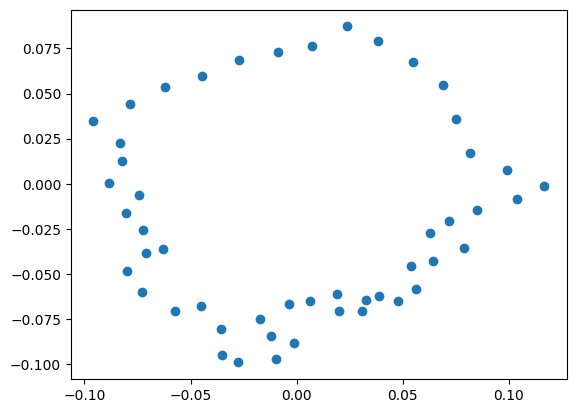

In [52]:
i = district_IDs.index("37_12")
plt.scatter(districts[:,i].real, districts[:,i].imag)
print(i)